<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/omds_modc_week2_banerjee_jayeeta_data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error,r2_score

In [8]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
713,16,1.0,16.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
604,23,3.0,17.0,2.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
120,33,1.0,16.0,4.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
208,27,4.0,16.0,1.0,0.0,0.0,0.000,1.0,0.67,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
380,18,3.0,15.0,1.0,1.0,2.0,0.003,1.0,0.58,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
813,20,1.0,17.0,NaN,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
575,17,2.0,15.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
266,21,2.0,19.0,1.0,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
557,27,2.0,17.0,3.0,0.0,0.0,0.000,1.0,0.25,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
822,36,3.0,20.0,2.0,0.0,0.0,0.000,1.0,6.00,0.0,...,16.0,16.0,1,0,1,1,0,0,0,0


In [9]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])

In [10]:
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

In [11]:
#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())


In [12]:
df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]

5-Fold Cross Validation Results (Linear Regression)
---------------------------------------------------
RMSE per fold: [0.2681874  0.24357822 0.23138839 0.24998339 0.23894214]
Mean RMSE: 0.2464159075365849
Std RMSE : 0.012461629934385699

R² per fold: [-0.00579439 -0.0199549  -0.04328909 -0.06652495  0.02560692]
Mean R²: -0.02199128095152971
Std R² : 0.031524335717559096

Test Set Results (Linear Regression)
------------------------------------
RMSE: 0.24324458923382838
R²: 0.02806056392904943
Accuracy: 0.9348837209302325


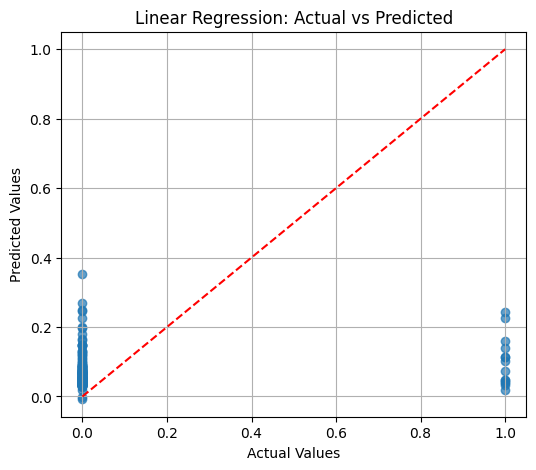

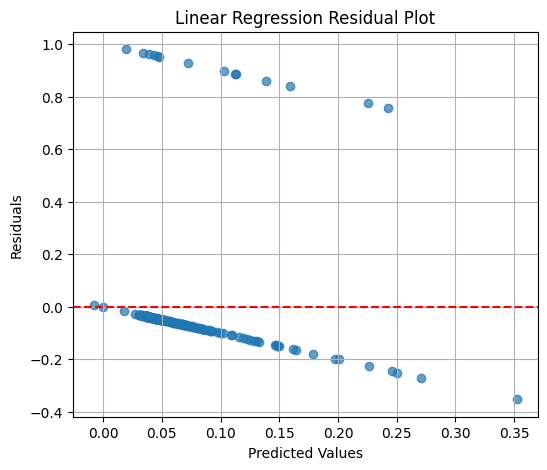

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

#-------------------------------------------------------
# Features and Target (Cervical Cancer Dataset)
#-------------------------------------------------------

df = df_CivicalCancer_nw.copy()

X = df.drop(columns=["Biopsy"])
y = df["Biopsy"]

#-------------------------------------------------------
# Train-Test Split (stratified for classification)
#-------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#-------------------------------------------------------
# Feature Scaling
#-------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#-------------------------------------------------------
# 5-Fold Cross Validation
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model1 = LinearRegression()

cv_scores = cross_validate(
    model1,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }
)

cv_rmse = -cv_scores['test_rmse']
cv_r2 = cv_scores['test_r2']

print("5-Fold Cross Validation Results (Linear Regression)")
print("---------------------------------------------------")
print("RMSE per fold:", cv_rmse)
print("Mean RMSE:", cv_rmse.mean())
print("Std RMSE :", cv_rmse.std())

print("\nR² per fold:", cv_r2)
print("Mean R²:", cv_r2.mean())
print("Std R² :", cv_r2.std())

#-------------------------------------------------------
# Train Final Model
#-------------------------------------------------------

model1.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred = model1.predict(X_test_scaled)
y_predClass = (y_pred >= 0.5).astype(int)

#-------------------------------------------------------
# Test Set Evaluation
#-------------------------------------------------------

model1_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
model1_r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_predClass)

print("\nTest Set Results (Linear Regression)")
print("------------------------------------")
print("RMSE:", model1_rmse)
print("R²:", model1_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.grid(True)
plt.show()

Best Alpha: 0.1
Best CV RMSE: 0.2379133938098592

Test Set Results (Lasso Regression)
----------------
RMSE: 0.24673463273051668
R²: -3.0056414692891664e-05
Accuracy: 0.9348837209302325

Top Lasso Features:
                               Feature  Coefficient
0                                  Age          0.0
1            Number of sexual partners         -0.0
2             First sexual intercourse          0.0
3                   Num of pregnancies          0.0
4                  Smokes (packs/year)          0.0
5      Hormonal Contraceptives (years)          0.0
6                          IUD (years)          0.0
7                        STDs (number)          0.0
8            STDs: Number of diagnosis          0.0
9                  STDs:condylomatosis          0.0
10  STDs:vulvo-perineal condylomatosis          0.0
11                       STDs:syphilis         -0.0
12    STDs:pelvic inflammatory disease         -0.0
13                 STDs:genital herpes          0.0
14          S

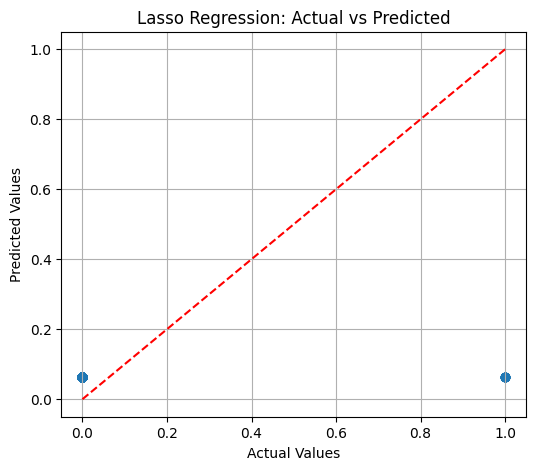

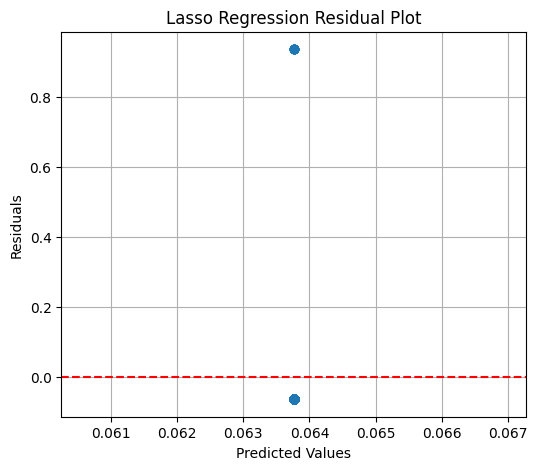

In [14]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#-------------------------------------------------------
# Hyperparameter Tuning using 5-Fold CV
#-------------------------------------------------------

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso = Lasso(max_iter=10000, random_state=42)

grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_['alpha'])
print("Best CV RMSE:", -grid.best_score_)

#-------------------------------------------------------
# Train Final Model (Best Estimator)
#-------------------------------------------------------

model2 = grid.best_estimator_
model2.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Prediction
#-------------------------------------------------------

y_pred2 = model2.predict(X_test_scaled)
y_predClass2 = (y_pred2 >= 0.5).astype(int)

#-------------------------------------------------------
# Evaluation on Test Set
#-------------------------------------------------------

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
lasso_r2 = r2_score(y_test, y_pred2)
accuracy = accuracy_score(y_test, y_predClass2)

print("\nTest Set Results (Lasso Regression)")
print("----------------")
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Feature Coefficients
#-------------------------------------------------------

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model2.coef_
})

coef = coef.sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop Lasso Features:")
print(coef.head(15))

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred2, alpha=0.7)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred2

plt.figure(figsize=(6,5))
plt.scatter(y_pred2, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Lasso Regression Residual Plot")
plt.grid(True)
plt.show()

Best Alpha: 100
Best CV RMSE: 0.24088268652970718

Test Set Results (Ridge Regression)
----------------
RMSE: 0.2436695674498903
R²: 0.0246614016600073
Accuracy: 0.9348837209302325

Top Ridge Features:
                               Feature  Coefficient
8            STDs: Number of diagnosis     0.029090
11                       STDs:syphilis    -0.021702
5      Hormonal Contraceptives (years)     0.011815
7                        STDs (number)     0.009925
6                          IUD (years)     0.007576
0                                  Age     0.007152
9                  STDs:condylomatosis    -0.006708
16                            STDs:HPV    -0.006705
15                    STDs:Hepatitis B    -0.005966
12    STDs:pelvic inflammatory disease    -0.005435
1            Number of sexual partners    -0.005361
3                   Num of pregnancies     0.004735
2             First sexual intercourse    -0.001701
10  STDs:vulvo-perineal condylomatosis     0.000591
4                 

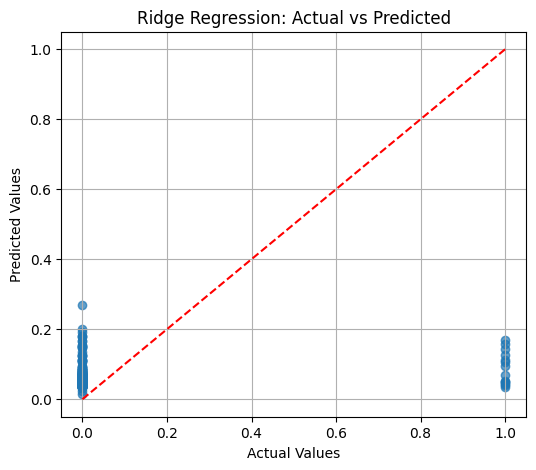

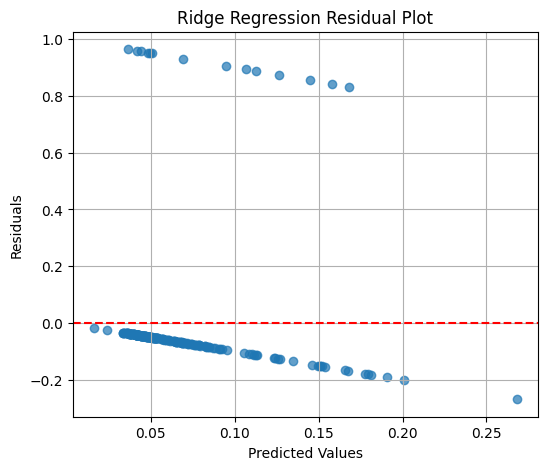

In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#-------------------------------------------------------
# Hyperparameter Tuning using 5-Fold Cross Validation
#-------------------------------------------------------

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 2, 5, 10, 20, 50, 100]
}

ridge = Ridge()

grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_['alpha'])
print("Best CV RMSE:", -grid.best_score_)

#-------------------------------------------------------
# Train Final Model (Best Estimator)
#-------------------------------------------------------

model3 = grid.best_estimator_
model3.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred3 = model3.predict(X_test_scaled)
y_predClass3 = (y_pred3 >= 0.5).astype(int)

#-------------------------------------------------------
# Test Set Evaluation
#-------------------------------------------------------

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
ridge_r2 = r2_score(y_test, y_pred3)
accuracy = accuracy_score(y_test, y_predClass3)

print("\nTest Set Results (Ridge Regression)")
print("----------------")
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Feature Coefficients
#-------------------------------------------------------

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model3.coef_
})

coef = coef.sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop Ridge Features:")
print(coef.head(15))

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred3, alpha=0.7)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred3

plt.figure(figsize=(6,5))
plt.scatter(y_pred3, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Ridge Regression Residual Plot")
plt.grid(True)
plt.show()

Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.4}
Best CV RMSE: 0.2379133938098592

Test Set Results (Elastic Net)
----------------
RMSE: 0.24673463273051668
R²: -3.0056414692891664e-05
Accuracy: 0.9348837209302325

Top Elastic Net Features:
                               Feature  Coefficient
0                                  Age          0.0
1            Number of sexual partners         -0.0
2             First sexual intercourse          0.0
3                   Num of pregnancies          0.0
4                  Smokes (packs/year)          0.0
5      Hormonal Contraceptives (years)          0.0
6                          IUD (years)          0.0
7                        STDs (number)          0.0
8            STDs: Number of diagnosis          0.0
9                  STDs:condylomatosis          0.0
10  STDs:vulvo-perineal condylomatosis          0.0
11                       STDs:syphilis         -0.0
12    STDs:pelvic inflammatory disease         -0.0
13                 STDs:genital

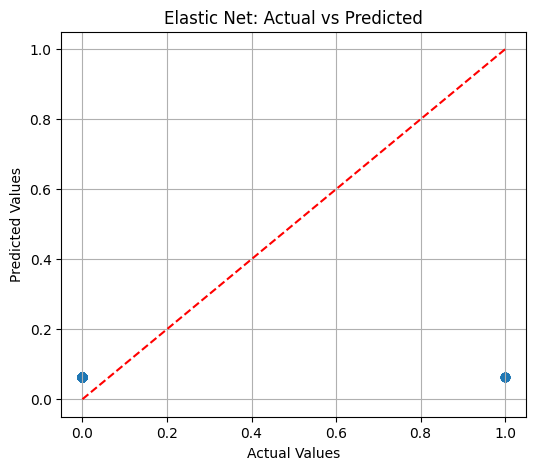

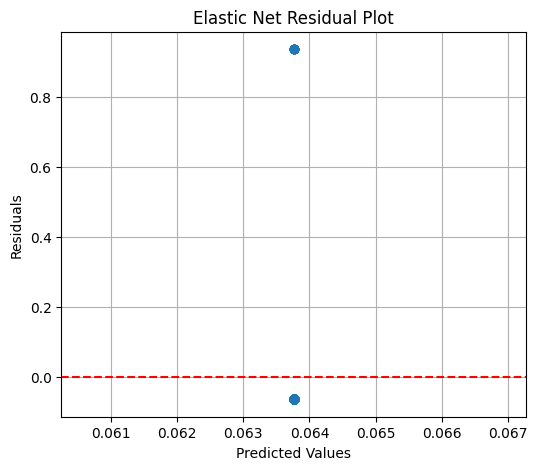

In [16]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#-------------------------------------------------------
# Hyperparameter Tuning using 5-Fold Cross Validation
#-------------------------------------------------------

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.4, 0.6, 0.8, 1.0]
}

enet = ElasticNet(max_iter=10000, random_state=42)

grid = GridSearchCV(
    estimator=enet,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

#-------------------------------------------------------
# Train Final Model (Best Estimator)
#-------------------------------------------------------

model4 = grid.best_estimator_
model4.fit(X_train_scaled, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred4 = model4.predict(X_test_scaled)
y_predClass4 = (y_pred4 >= 0.5).astype(int)

#-------------------------------------------------------
# Test Set Evaluation
#-------------------------------------------------------

enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred4))
enet_r2 = r2_score(y_test, y_pred4)
accuracy = accuracy_score(y_test, y_predClass4)

print("\nTest Set Results (Elastic Net)")
print("----------------")
print("RMSE:", enet_rmse)
print("R²:", enet_r2)
print("Accuracy:", accuracy)

#-------------------------------------------------------
# Feature Coefficients
#-------------------------------------------------------

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model4.coef_
})

coef = coef.sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop Elastic Net Features:")
print(coef.head(15))

#-------------------------------------------------------
# Actual vs Predicted Plot
#-------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred4, alpha=0.7)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Elastic Net: Actual vs Predicted")
plt.grid(True)
plt.show()

#-------------------------------------------------------
# Residual Plot
#-------------------------------------------------------

residuals = y_test - y_pred4

plt.figure(figsize=(6,5))
plt.scatter(y_pred4, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Elastic Net Residual Plot")
plt.grid(True)
plt.show()